# **4. Systems of Linear Equations**

## What is a System of Linear Equations?
A **system of linear equations** is a collection of equations that we want to solve simultaneously:

$$\begin{cases} 2x + 3y = 8 \\ x - y = 1 \end{cases}$$

In **matrix form**, this becomes:

$$A\vec{x} = \vec{b}$$

$$\begin{bmatrix} 2 & 3 \\ 1 & -1 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 8 \\ 1 \end{bmatrix}$$

### Why This Matters in Data Science

| Application | System of Equations |
|-------------|--------------------|
| **Linear Regression** | Finding $w$ in $Xw = y$ |
| **Network Flow** | Balance equations at nodes |
| **Markov Chains** | Steady-state probabilities |
| **Least Squares** | Minimizing $\|Ax - b\|^2$ |

### Three Possible Outcomes

| Outcome | Geometric Meaning | Condition |
|---------|-------------------|----------|
| **One unique solution** | Lines intersect at one point | $\det(A) \neq 0$ |
| **No solution** | Lines are parallel | Inconsistent system |
| **Infinitely many solutions** | Lines overlap | Dependent equations |

THREE TYPES OF LINEAR SYSTEMS


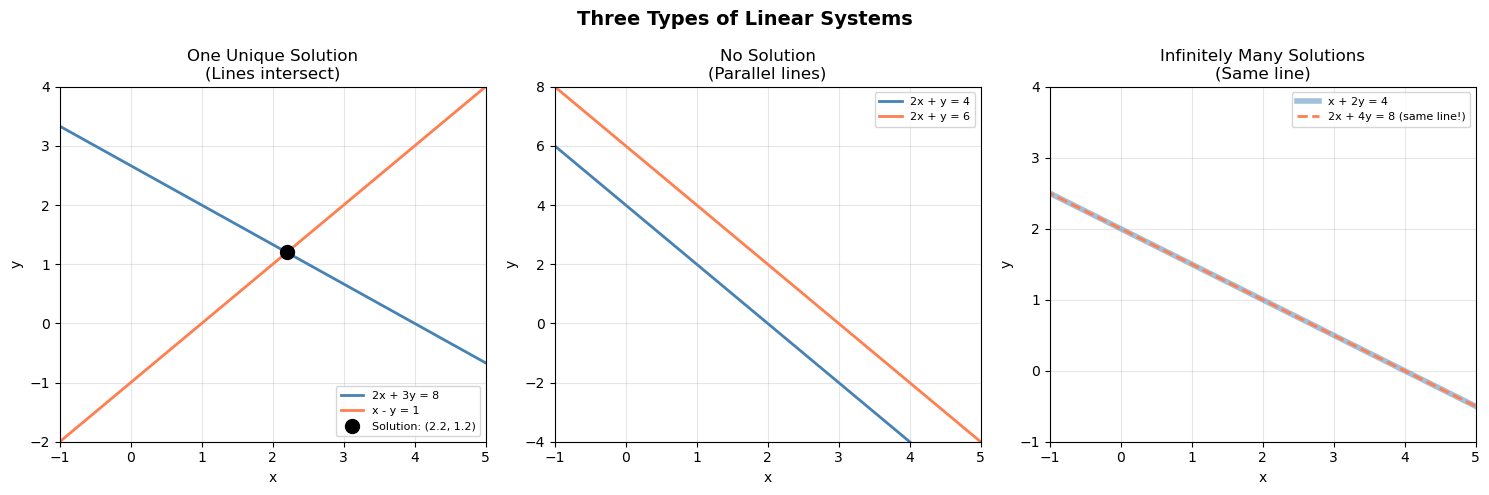

In [1]:
# ===============================================
# VISUALIZING SYSTEMS OF EQUATIONS
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import solve, det, inv
import sympy as sp

print("=" * 50)
print("THREE TYPES OF LINEAR SYSTEMS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.linspace(-2, 6, 100)

# Case 1: Unique solution
ax = axes[0]
# 2x + 3y = 8  →  y = (8 - 2x)/3
# x - y = 1    →  y = x - 1
y1 = (8 - 2*x) / 3
y2 = x - 1
ax.plot(x, y1, 'steelblue', linewidth=2, label='2x + 3y = 8')
ax.plot(x, y2, 'coral', linewidth=2, label='x - y = 1')
# Solution: x=2.2, y=1.2
sol = np.linalg.solve(np.array([[2, 3], [1, -1]]), np.array([8, 1]))
ax.plot(sol[0], sol[1], 'ko', markersize=10, zorder=5,
        label=f'Solution: ({sol[0]:.1f}, {sol[1]:.1f})')
ax.set_xlim(-1, 5)
ax.set_ylim(-2, 4)
ax.grid(True, alpha=0.3)
ax.set_title('One Unique Solution\n(Lines intersect)')
ax.legend(fontsize=8)
ax.set_xlabel('x')
ax.set_ylabel('y')

# Case 2: No solution (parallel lines)
ax = axes[1]
# 2x + y = 4  →  y = 4 - 2x
# 2x + y = 6  →  y = 6 - 2x
y1 = 4 - 2*x
y2 = 6 - 2*x
ax.plot(x, y1, 'steelblue', linewidth=2, label='2x + y = 4')
ax.plot(x, y2, 'coral', linewidth=2, label='2x + y = 6')
ax.set_xlim(-1, 5)
ax.set_ylim(-4, 8)
ax.grid(True, alpha=0.3)
ax.set_title('No Solution\n(Parallel lines)')
ax.legend(fontsize=8)
ax.set_xlabel('x')
ax.set_ylabel('y')

# Case 3: Infinite solutions (same line)
ax = axes[2]
# x + 2y = 4  →  y = (4 - x)/2
# 2x + 4y = 8 →  y = (8 - 2x)/4 = (4 - x)/2
y1 = (4 - x) / 2
ax.plot(x, y1, 'steelblue', linewidth=4, alpha=0.5, label='x + 2y = 4')
ax.plot(x, y1, 'coral', linewidth=2, linestyle='--', label='2x + 4y = 8 (same line!)')
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.grid(True, alpha=0.3)
ax.set_title('Infinitely Many Solutions\n(Same line)')
ax.legend(fontsize=8)
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.suptitle('Three Types of Linear Systems', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Solving Systems of Equations

### Method 1: Matrix Inverse
If $A$ is invertible ($\det(A) \neq 0$):

$$A\vec{x} = \vec{b} \implies \vec{x} = A^{-1}\vec{b}$$

### Method 2: NumPy's `np.linalg.solve()`
More numerically stable than computing the inverse directly.

### Method 3: SymPy (Symbolic)
For exact solutions with fractions and symbols.

In [2]:
# ===============================================
# SOLVING SYSTEMS OF EQUATIONS
# ===============================================

print("=" * 50)
print("SOLVING SYSTEMS OF EQUATIONS")
print("=" * 50)

# System: 2x + 3y = 8
#         x  - y  = 1

A = np.array([[2, 3],
              [1, -1]])
b = np.array([8, 1])

print(f"\nSystem:")
print(f"  2x + 3y = 8")
print(f"   x -  y = 1")
print(f"\nMatrix form: Ax = b")
print(f"A = \n{A}")
print(f"b = {b}")

# Method 1: Using inverse
print("\n" + "-" * 50)
print("METHOD 1: Matrix Inverse")
print("-" * 50)
A_inv = inv(A)
x_inv = A_inv @ b
print(f"det(A) = {det(A):.0f} (≠ 0, so A is invertible)")
print(f"x = A⁻¹b = {x_inv}")
print(f"Solution: x = {x_inv[0]:.2f}, y = {x_inv[1]:.2f}")

# Method 2: np.linalg.solve
print("\n" + "-" * 50)
print("METHOD 2: np.linalg.solve() [Recommended]")
print("-" * 50)
x_solve = solve(A, b)
print(f"x = {x_solve}")
print(f"Solution: x = {x_solve[0]:.2f}, y = {x_solve[1]:.2f}")

# Method 3: SymPy (exact)
print("\n" + "-" * 50)
print("METHOD 3: SymPy (Symbolic/Exact)")
print("-" * 50)
x_sym, y_sym = sp.symbols('x y')
eq1 = sp.Eq(2*x_sym + 3*y_sym, 8)
eq2 = sp.Eq(x_sym - y_sym, 1)
solution = sp.solve([eq1, eq2], [x_sym, y_sym])
print(f"Exact solution: {solution}")

# Verify
print(f"\nVerification:")
print(f"  2({x_solve[0]:.2f}) + 3({x_solve[1]:.2f}) = {2*x_solve[0] + 3*x_solve[1]:.2f} (should be 8)")
print(f"  {x_solve[0]:.2f} - {x_solve[1]:.2f} = {x_solve[0] - x_solve[1]:.2f} (should be 1)")

SOLVING SYSTEMS OF EQUATIONS

System:
  2x + 3y = 8
   x -  y = 1

Matrix form: Ax = b
A = 
[[ 2  3]
 [ 1 -1]]
b = [8 1]

--------------------------------------------------
METHOD 1: Matrix Inverse
--------------------------------------------------
det(A) = -5 (≠ 0, so A is invertible)
x = A⁻¹b = [2.2 1.2]
Solution: x = 2.20, y = 1.20

--------------------------------------------------
METHOD 2: np.linalg.solve() [Recommended]
--------------------------------------------------
x = [2.2 1.2]
Solution: x = 2.20, y = 1.20

--------------------------------------------------
METHOD 3: SymPy (Symbolic/Exact)
--------------------------------------------------
Exact solution: {x: 11/5, y: 6/5}

Verification:
  2(2.20) + 3(1.20) = 8.00 (should be 8)
  2.20 - 1.20 = 1.00 (should be 1)


In [3]:
# ===============================================
# SOLVING A LARGER SYSTEM (3 VARIABLES)
# ===============================================

print("=" * 50)
print("3-VARIABLE SYSTEM")
print("=" * 50)

# System:
# 2x + y - z = 1
# x + 3y + 2z = 12
# 3x + 2y + z = 8

A = np.array([[2, 1, -1],
              [1, 3,  2],
              [3, 2,  1]])
b = np.array([1, 12, 8])

print(f"\nSystem:")
print(f"  2x +  y -  z = 1")
print(f"   x + 3y + 2z = 12")
print(f"  3x + 2y +  z = 8")

print(f"\ndet(A) = {det(A):.2f}")

solution = solve(A, b)
print(f"\nSolution: x = {solution[0]:.4f}, y = {solution[1]:.4f}, z = {solution[2]:.4f}")

# Verify
print(f"\nVerification (A @ x should equal b):")
result = A @ solution
print(f"  A @ x = {np.round(result, 4)}")
print(f"  b     = {b}")
print(f"  Match? {np.allclose(result, b)}")

3-VARIABLE SYSTEM

System:
  2x +  y -  z = 1
   x + 3y + 2z = 12
  3x + 2y +  z = 8

det(A) = 10.00

Solution: x = 0.3000, y = 2.5000, z = 2.1000

Verification (A @ x should equal b):
  A @ x = [ 1. 12.  8.]
  b     = [ 1 12  8]
  Match? True


---
## Overdetermined Systems and Least Squares

In data science, we often have **more equations than unknowns** (more data points than parameters). These systems are **overdetermined** and typically have no exact solution.

Instead, we find the **best approximate solution** that minimizes the error:

$$\min_{\vec{x}} \|A\vec{x} - \vec{b}\|^2$$

The solution is given by the **normal equation**:

$$\vec{x} = (A^T A)^{-1} A^T \vec{b}$$

This is exactly how **linear regression** works!

LEAST SQUARES (LINEAR REGRESSION)

Data: 20 points
A shape: (20, 2) (overdetermined — more rows than columns!)

Normal equation: x = (AᵀA)⁻¹ Aᵀb
  slope = 1.6217
  intercept = 1.7746

np.linalg.lstsq:
  slope = 1.6217
  intercept = 1.7746


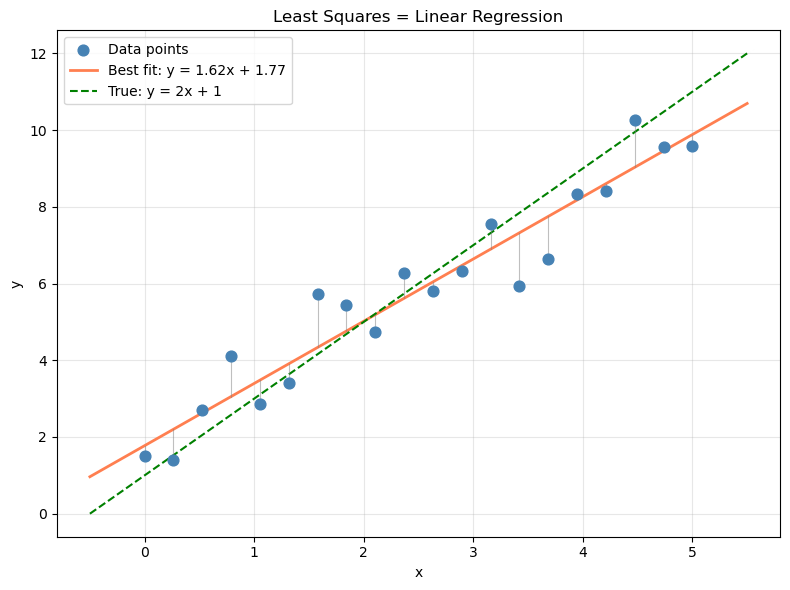


Key insight: Linear regression IS solving a system of equations
using least squares!


In [4]:
# ===============================================
# LEAST SQUARES: LINEAR REGRESSION CONNECTION
# ===============================================

print("=" * 50)
print("LEAST SQUARES (LINEAR REGRESSION)")
print("=" * 50)

# Generate some data: y ≈ 2x + 1 + noise
np.random.seed(42)
n = 20
x_data = np.linspace(0, 5, n)
y_data = 2 * x_data + 1 + np.random.normal(0, 1, n)

# Set up as Ax = b where we want to find slope and intercept
# y = mx + b  →  [x, 1] @ [m, b]^T = y
A = np.column_stack([x_data, np.ones(n)])
b = y_data

print(f"\nData: {n} points")
print(f"A shape: {A.shape} (overdetermined — more rows than columns!)")

# Method 1: Normal equation
x_normal = inv(A.T @ A) @ A.T @ b
print(f"\nNormal equation: x = (AᵀA)⁻¹ Aᵀb")
print(f"  slope = {x_normal[0]:.4f}")
print(f"  intercept = {x_normal[1]:.4f}")

# Method 2: np.linalg.lstsq
x_lstsq, residuals, rank, sv = np.linalg.lstsq(A, b, rcond=None)
print(f"\nnp.linalg.lstsq:")
print(f"  slope = {x_lstsq[0]:.4f}")
print(f"  intercept = {x_lstsq[1]:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(x_data, y_data, color='steelblue', s=60, zorder=5, label='Data points')

# Best fit line
x_line = np.linspace(-0.5, 5.5, 100)
y_line = x_normal[0] * x_line + x_normal[1]
ax.plot(x_line, y_line, 'coral', linewidth=2,
        label=f'Best fit: y = {x_normal[0]:.2f}x + {x_normal[1]:.2f}')

# True line
y_true = 2 * x_line + 1
ax.plot(x_line, y_true, 'green', linewidth=1.5, linestyle='--',
        label='True: y = 2x + 1')

# Show residuals
y_pred = x_normal[0] * x_data + x_normal[1]
for xi, yi, yp in zip(x_data, y_data, y_pred):
    ax.plot([xi, xi], [yi, yp], 'gray', linewidth=0.8, alpha=0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Least Squares = Linear Regression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKey insight: Linear regression IS solving a system of equations")
print(f"using least squares!")

---
## Summary

| Concept | Formula | When to Use |
|---------|---------|------------|
| **Matrix form** | $A\vec{x} = \vec{b}$ | Setting up the problem |
| **Inverse method** | $\vec{x} = A^{-1}\vec{b}$ | Small, square systems |
| **np.linalg.solve** | Numerically stable | Square systems (recommended) |
| **Least squares** | $\vec{x} = (A^TA)^{-1}A^T\vec{b}$ | Overdetermined systems |
| **np.linalg.lstsq** | Numerically stable | Overdetermined (recommended) |

### Key Takeaway
Linear regression is fundamentally about solving a system of linear equations using least squares. The **normal equation** $(A^TA)^{-1}A^Tb$ is the bridge between linear algebra and machine learning.